Titulo: 08_offsides_maps
Objetivo: estudiar los fuera de juego del torneo con maps de mplsoccer, separando los pases que acaban en offside (Pass Offside) y los eventos explicitamente etiquetados como Offside.

0) Imports

In [45]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch, VerticalPitch


1) Carga de datos

In [46]:
DATA_PATH = "../data/processed/events.parquet"
events = pd.read_parquet(DATA_PATH) if DATA_PATH.endswith(".parquet") else pd.read_csv(DATA_PATH)
events.head()


,match_id,event_id,index,period,timestamp,minute,second,type,possession,possession_team,...,dribble_no_touch,shot_outcome,shot_statsbomb_xg,shot_body_part,shot_type,shot_technique,shot_first_time,shot_one_on_one,shot_open_goal,shot_aerial_won
0,3930158,f2207d37-beed-4073-84a5-f9d696e2afdd,1,1,00:00:00.000,0,0,Starting XI,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
1,3930158,43e494fe-4871-4b2a-a509-a325c17a5e3f,2,1,00:00:00.000,0,0,Starting XI,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
2,3930158,d9de8fe7-3122-4067-a1c2-a742c7edb2b8,3,1,00:00:00.000,0,0,Half Start,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
3,3930158,455f819f-3926-4ed4-a0e9-4e9e4d0bf95a,4,1,00:00:00.000,0,0,Half Start,1,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None
4,3930158,df6f6fb7-f0b0-4561-9171-f4172f5e97e7,5,1,00:00:01.191,0,1,Pass,2,Germany,...,None,NaN,NaN,NaN,NaN,NaN,None,None,None,None


2) Normalizacion minima (type/team/player + x,y,end_x,end_y)

In [47]:
def _unpack_xy(series, idx):
    return series.apply(lambda v: v[idx] if isinstance(v, (list, tuple)) and len(v) > idx else np.nan)

if "type" not in events.columns and "type.name" in events.columns:
    events["type"] = events["type.name"]
elif "type.name" in events.columns:
    events["type"] = events["type.name"]

if "team" not in events.columns and "team.name" in events.columns:
    events["team"] = events["team.name"]
if "player" not in events.columns and "player.name" in events.columns:
    events["player"] = events["player.name"]
if "pass_recipient" not in events.columns and "pass.recipient.name" in events.columns:
    events["pass_recipient"] = events["pass.recipient.name"]
if "pass_outcome" not in events.columns and "pass.outcome.name" in events.columns:
    events["pass_outcome"] = events["pass.outcome.name"]
if "pass_length" not in events.columns and "pass.length" in events.columns:
    events["pass_length"] = events["pass.length"]
if "play_pattern" not in events.columns and "play_pattern.name" in events.columns:
    events["play_pattern"] = events["play_pattern.name"]

if "location" in events.columns and not {"x", "y"}.issubset(events.columns):
    events["x"] = _unpack_xy(events["location"], 0)
    events["y"] = _unpack_xy(events["location"], 1)
elif not {"x", "y"}.issubset(events.columns):
    raise ValueError("No encuentro 'location' ni columnas 'x','y'. Ajusta el mapeo.")

if "end_location" in events.columns and not {"end_x", "end_y"}.issubset(events.columns):
    events["end_x"] = _unpack_xy(events["end_location"], 0)
    events["end_y"] = _unpack_xy(events["end_location"], 1)

events[["type", "team", "player", "x", "y"]].head()


,type,team,player,x,y
0,Starting XI,Germany,NaN,NaN,NaN
1,Starting XI,Scotland,NaN,NaN,NaN
2,Half Start,Germany,NaN,NaN,NaN
3,Half Start,Scotland,NaN,NaN,NaN
4,Pass,Germany,Kai Havertz,61.0,40.1


3) Filtrar offsides: pases que acaban en offside + eventos Offside

In [48]:
passes = events[events["type"].eq("Pass")].copy()
offside_passes = passes[passes["pass_outcome"].eq("Pass Offside")].copy()

if offside_passes.empty:
    raise ValueError("No hay pases con pass_outcome == 'Pass Offside' en el dataset.")

offside_targets = offside_passes.copy()
offside_targets["offside_player"] = offside_targets["pass_recipient"].fillna("Unknown")
offside_targets["passer"] = offside_targets["player"]
offside_targets["offside_x"] = offside_targets["end_x"]
offside_targets["offside_y"] = offside_targets["end_y"]
offside_targets["is_long"] = offside_targets["pass_length"].fillna(0) >= 30
offside_targets["is_set_piece"] = ~offside_targets["play_pattern"].fillna("Regular Play").eq("Regular Play")
offside_targets["third"] = pd.cut(
    offside_targets["offside_x"],
    bins=[0, 40, 80, 120],
    labels=["Defensive third", "Middle third", "Final third"],
    include_lowest=True,
)

offside_events = events[events["type"].eq("Offside")].copy()

{
    "pass_offside_rows": len(offside_targets),
    "offside_event_rows": len(offside_events),
    "teams_with_pass_offside": int(offside_targets["team"].nunique()),
    "players_flagged_offside": int(offside_targets["offside_player"].nunique()),
}


{'pass_offside_rows': 146,
 'offside_event_rows': 15,
 'teams_with_pass_offside': 23,
 'players_flagged_offside': 91}

4) Vista rapida de las columnas utiles

In [49]:
offside_targets[[
    "match_id", "team", "passer", "offside_player",
    "x", "y", "offside_x", "offside_y",
    "pass_length", "play_pattern", "third"
]].head()


,match_id,team,passer,offside_player,x,y,offside_x,offside_y,pass_length,play_pattern,third
59,3930158,Germany,Antonio Rüdiger,Florian Wirtz,48.2,49.1,97.1,30.7,52.247200,From Kick Off,Final third
2774,3930158,Germany,Pascal Groß,Jonathan Tah,90.8,53.9,111.2,21.2,38.541534,From Corner,Final third
2818,3930158,Germany,Thomas Müller,Niclas Füllkrug,98.5,16.9,108.8,44.8,29.740545,Regular Play,Final third
3220,3930158,Germany,Maximilian Mittelstädt,Niclas Füllkrug,109.2,12.7,112.3,34.1,21.623367,From Kick Off,Final third
3451,3930159,Switzerland,Granit Xhaka,Michel Aebischer,96.9,29.3,110.3,30.2,13.430190,Regular Play,Final third


5) Helpers de plotting

In [50]:
def draw_pitch(title=None, vertical=False):
    pitch = VerticalPitch(pitch_type="statsbomb", line_zorder=2) if vertical else Pitch(pitch_type="statsbomb", line_zorder=2)
    fig, ax = pitch.draw(figsize=(10, 7))
    if title:
        fig.suptitle(title, fontsize=14)
    return pitch, fig, ax

def plot_offside_targets(df, title, vertical=False, s=65, alpha=0.75, color="crimson"):
    pitch, fig, ax = draw_pitch(title=title, vertical=vertical)
    pitch.scatter(df["offside_x"], df["offside_y"], ax=ax, s=s, alpha=alpha, color=color, edgecolors="black", linewidth=0.5)
    return fig, ax

def plot_offside_passes(df, title, vertical=False, arrow_color="black", point_color="crimson", alpha=0.55):
    pitch, fig, ax = draw_pitch(title=title, vertical=vertical)
    pitch.arrows(
        df["x"], df["y"],
        df["offside_x"], df["offside_y"],
        ax=ax,
        width=1.6,
        headwidth=4,
        headlength=4,
        color=arrow_color,
        alpha=alpha,
    )
    pitch.scatter(
        df["offside_x"], df["offside_y"],
        ax=ax,
        s=70,
        color=point_color,
        edgecolors="black",
        linewidth=0.5,
        zorder=3,
    )
    return fig, ax


6) Vista global de la competicion (color por equipo)

C:\Users\javie\AppData\Local\Temp\ipykernel_24232\2426898737.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(teams))


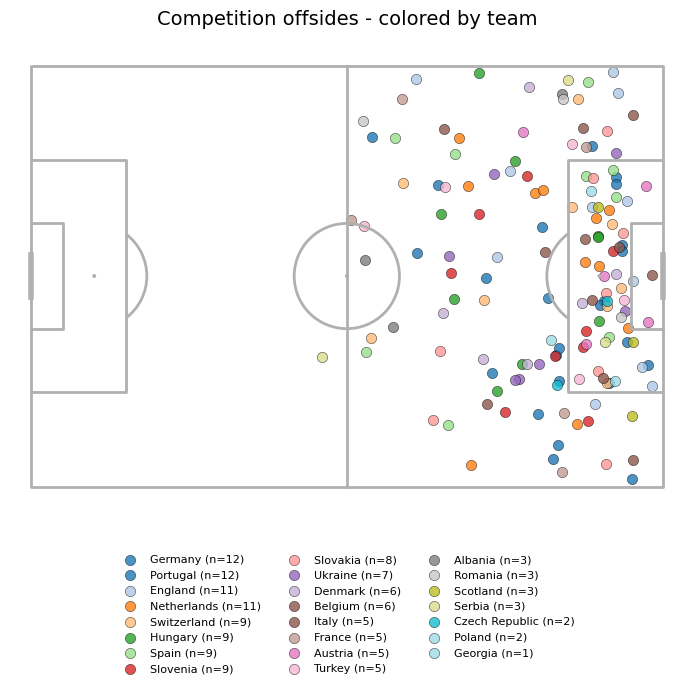

team
Germany           12
Portugal          12
England           11
Netherlands       11
Switzerland        9
Hungary            9
Spain              9
Slovenia           9
Slovakia           8
Ukraine            7
Denmark            6
Belgium            6
Italy              5
France             5
Austria            5
Turkey             5
Albania            3
Romania            3
Scotland           3
Serbia             3
Czech Republic     2
Poland             2
Georgia            1
Name: count, dtype: int64

In [51]:
team_counts = offside_targets["team"].value_counts().sort_values(ascending=False)
teams = team_counts.index.tolist()
cmap = plt.cm.get_cmap("tab20", len(teams))
team_colors = {team: cmap(i) for i, team in enumerate(teams)}

pitch, fig, ax = draw_pitch(title="Competition offsides - colored by team")

for team in teams:
    df_plot = offside_targets[offside_targets["team"].eq(team)]
    pitch.scatter(
        df_plot["offside_x"], df_plot["offside_y"],
        ax=ax,
        s=55,
        alpha=0.8,
        color=[team_colors[team]],
        edgecolors="black",
        linewidth=0.35,
        label=f"{team} (n={len(df_plot)})",
    )

ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8, frameon=False)
plt.show()

team_counts


7) Mapa de offsides por equipo (posicion final del jugador en offside)

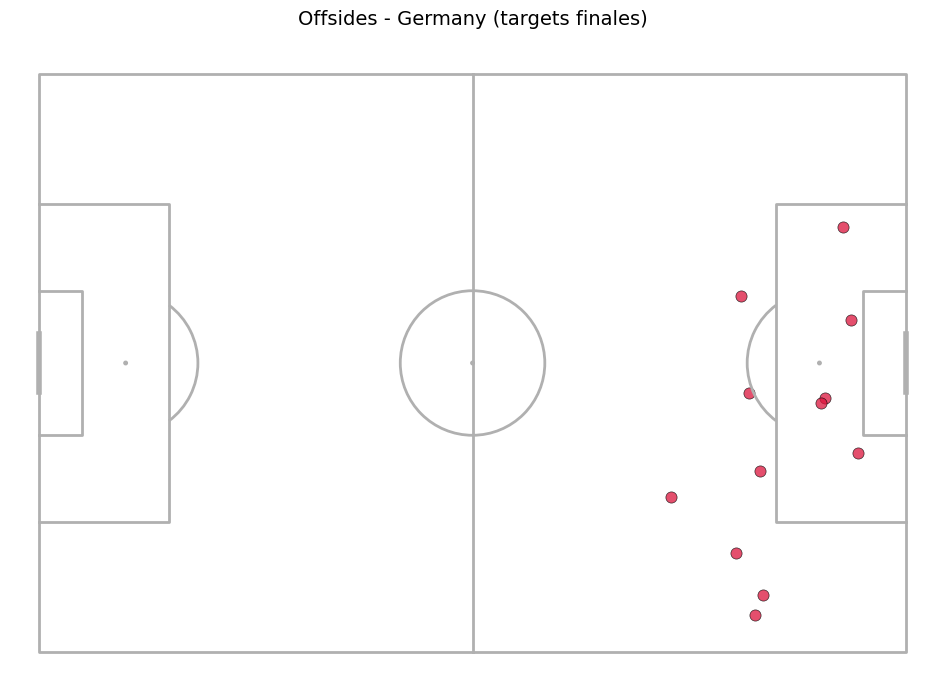

In [52]:
TEAM = offside_targets["team"].dropna().value_counts().index[0]
team_off = offside_targets[offside_targets["team"].eq(TEAM)].copy()

fig, ax = plot_offside_targets(team_off, title=f"Offsides - {TEAM} (targets finales)")
plt.show()


8) Pases que acaban en fuera de juego

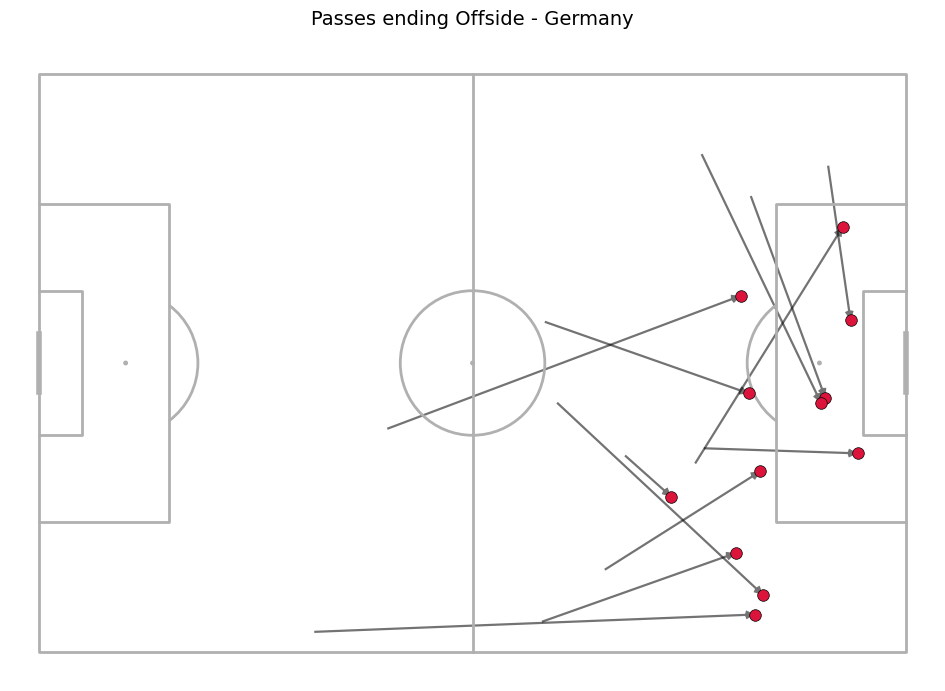

In [53]:
fig, ax = plot_offside_passes(team_off, title=f"Passes ending Offside - {TEAM}")
plt.show()


9) Top pasadores y top receptores en offside

In [54]:
TEAM = offside_targets["team"].dropna().value_counts().index[0]
team_off = offside_targets[offside_targets["team"].eq(TEAM)].copy()

top_passers = team_off["passer"].value_counts().head(10)
top_receivers = team_off["offside_player"].value_counts().head(10)

top_passers, top_receivers


(passer
 Maximilian Mittelstädt    2
 Joshua Kimmich            2
 Toni Kroos                2
 Antonio Rüdiger           1
 Pascal Groß               1
 Thomas Müller             1
 Leroy Sané                1
 Florian Wirtz             1
 Niclas Füllkrug           1
 Name: count, dtype: int64,
 offside_player
 Niclas Füllkrug    4
 Kai Havertz        3
 Florian Wirtz      2
 Jonathan Tah       1
 İlkay Gündoğan     1
 Joshua Kimmich     1
 Name: count, dtype: int64)

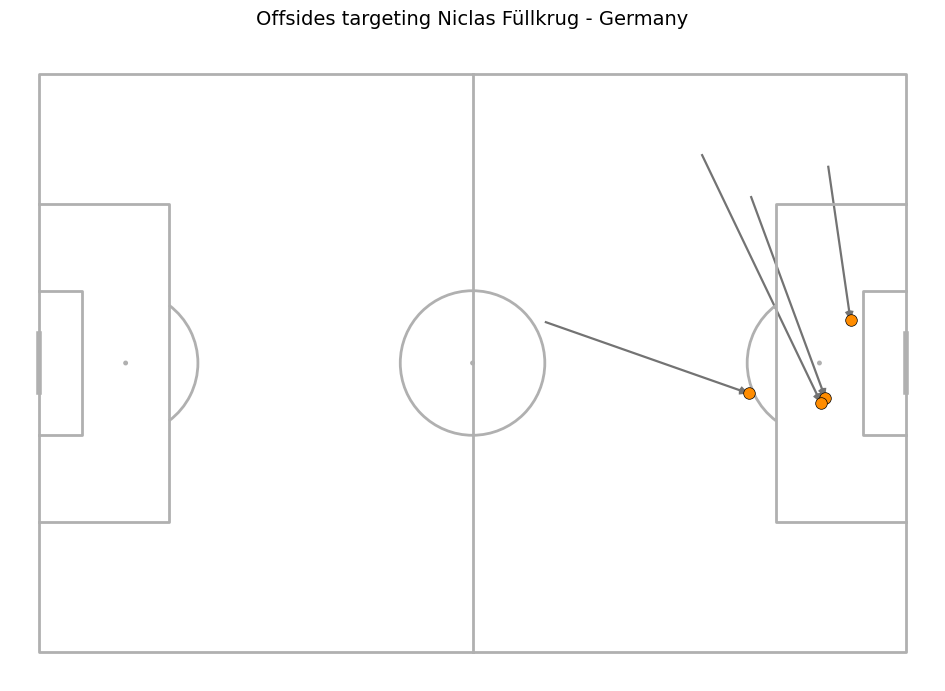

In [55]:
RECEIVER = top_receivers.index[0]
receiver_df = team_off[team_off["offside_player"].eq(RECEIVER)].copy()

fig, ax = plot_offside_passes(receiver_df, title=f"Offsides targeting {RECEIVER} - {TEAM}", point_color="darkorange")
plt.show()


10) Heatmap de zonas de offside

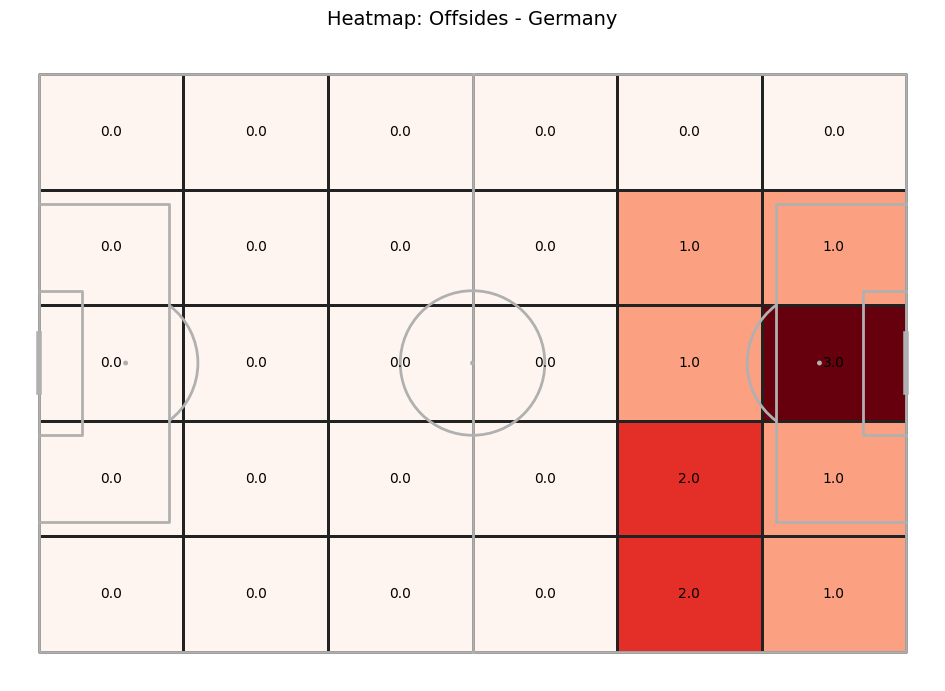

In [56]:
pitch, fig, ax = draw_pitch(title=f"Heatmap: Offsides - {TEAM}")
bin_stat = pitch.bin_statistic(team_off["offside_x"], team_off["offside_y"], statistic="count", bins=(6, 5))
pitch.heatmap(bin_stat, ax=ax, cmap="Reds", edgecolors="#222222")
pitch.label_heatmap(bin_stat, color="black", fontsize=10, ax=ax, ha="center", va="center")
plt.show()


11) Offsides por tercios del campo

In [57]:
TEAM = offside_targets["team"].dropna().value_counts().index[0]
team_off = offside_targets[offside_targets["team"].eq(TEAM)].copy()
team_off["third"].value_counts(dropna=False)


third
Final third        12
Defensive third     0
Middle third        0
Name: count, dtype: int64

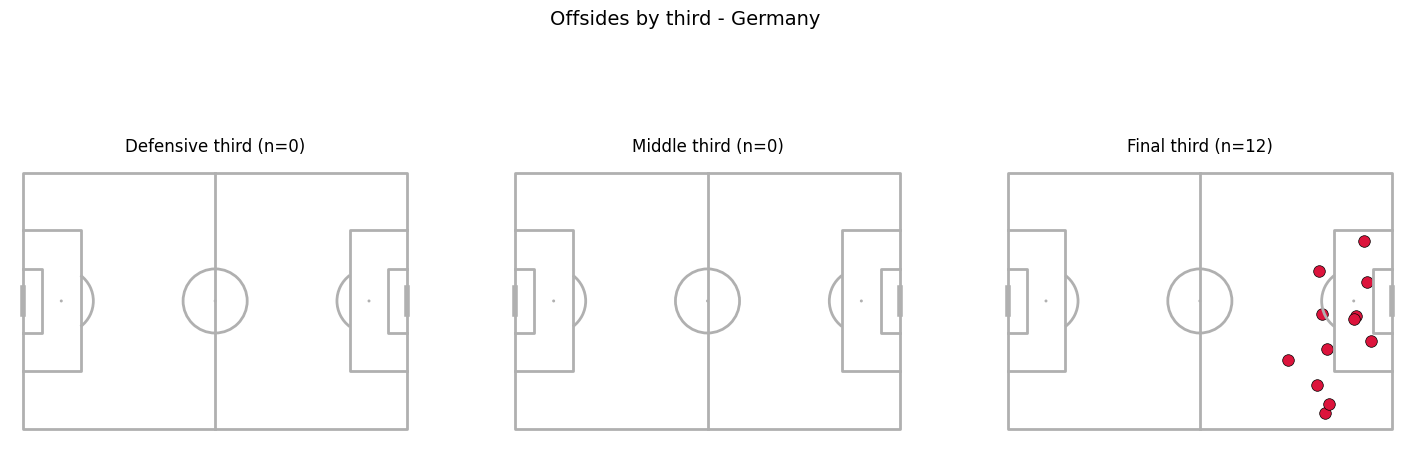

In [58]:
third_order = ["Defensive third", "Middle third", "Final third"]
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, third in zip(axes, third_order):
    third_df = team_off[team_off["third"].astype(str).eq(third)].copy()
    pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
    pitch.draw(ax=ax)
    if not third_df.empty:
        pitch.scatter(
            third_df["offside_x"], third_df["offside_y"],
            ax=ax, s=70, color="crimson", edgecolors="black", linewidth=0.5
        )
    ax.set_title(f"{third} (n={len(third_df)})")

fig.suptitle(f"Offsides by third - {TEAM}", fontsize=14)
plt.show()


12) Offsides por tipo de jugada

In [59]:
TEAM = offside_targets["team"].dropna().value_counts().index[0]
team_off = offside_targets[offside_targets["team"].eq(TEAM)].copy()
team_off["play_pattern"].value_counts().head(10)


play_pattern
Regular Play      4
From Throw In     3
From Kick Off     2
From Corner       1
From Keeper       1
From Free Kick    1
Name: count, dtype: int64

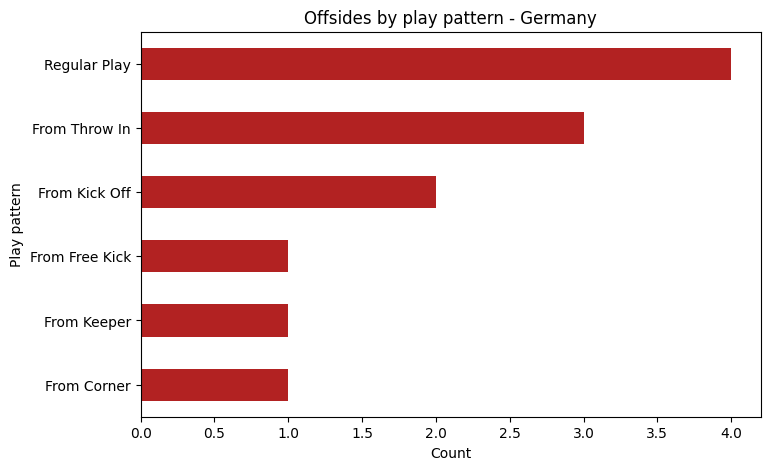

In [60]:
play_counts = team_off["play_pattern"].value_counts().head(8).sort_values()
ax = play_counts.plot(kind="barh", figsize=(8, 5), color="firebrick")
ax.set_title(f"Offsides by play pattern - {TEAM}")
ax.set_xlabel("Count")
ax.set_ylabel("Play pattern")
plt.show()


13) Pases largos vs cortos que acaban en offside

In [61]:
TEAM = offside_targets["team"].dropna().value_counts().index[0]
team_off = offside_targets[offside_targets["team"].eq(TEAM)].copy()

team_off["pass_type_len"] = np.where(team_off["is_long"], "Long (>=30)", "Short (<30)")
team_off["pass_type_len"].value_counts()


pass_type_len
Short (<30)    7
Long (>=30)    5
Name: count, dtype: int64

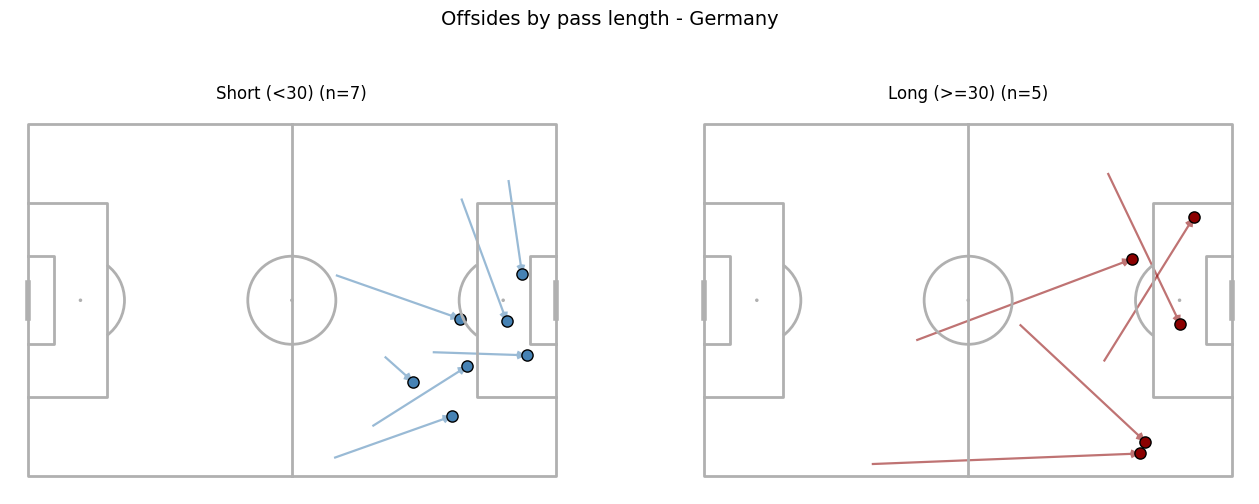

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, color in zip(axes, ["Short (<30)", "Long (>=30)"], ["steelblue", "darkred"]):
    df_plot = team_off[team_off["pass_type_len"].eq(label)]
    pitch = Pitch(pitch_type="statsbomb", line_zorder=2)
    pitch.draw(ax=ax)
    if not df_plot.empty:
        pitch.arrows(
            df_plot["x"], df_plot["y"], df_plot["offside_x"], df_plot["offside_y"],
            ax=ax, width=1.6, headwidth=4, headlength=4, color=color, alpha=0.55
        )
        pitch.scatter(df_plot["offside_x"], df_plot["offside_y"], ax=ax, s=65, color=color, edgecolors="black")
    ax.set_title(f"{label} (n={len(df_plot)})")

fig.suptitle(f"Offsides by pass length - {TEAM}", fontsize=14)
plt.show()


14) Partidos con mas offsides

In [63]:
match_team_counts = (
    offside_targets.groupby(["match_id", "team"]).size()
    .rename("offsides")
    .reset_index()
    .sort_values(["offsides", "match_id"], ascending=[False, True])
)
match_team_counts.head(15)


,match_id,team,offsides
55,3941020,Slovenia,6
15,3930169,Switzerland,5
23,3930177,Hungary,5
0,3930158,Germany,4
18,3930174,Portugal,4
19,3930175,Belgium,4
41,3938640,Ukraine,4
49,3940983,Germany,4
54,3941020,Portugal,4
63,3942382,Netherlands,4


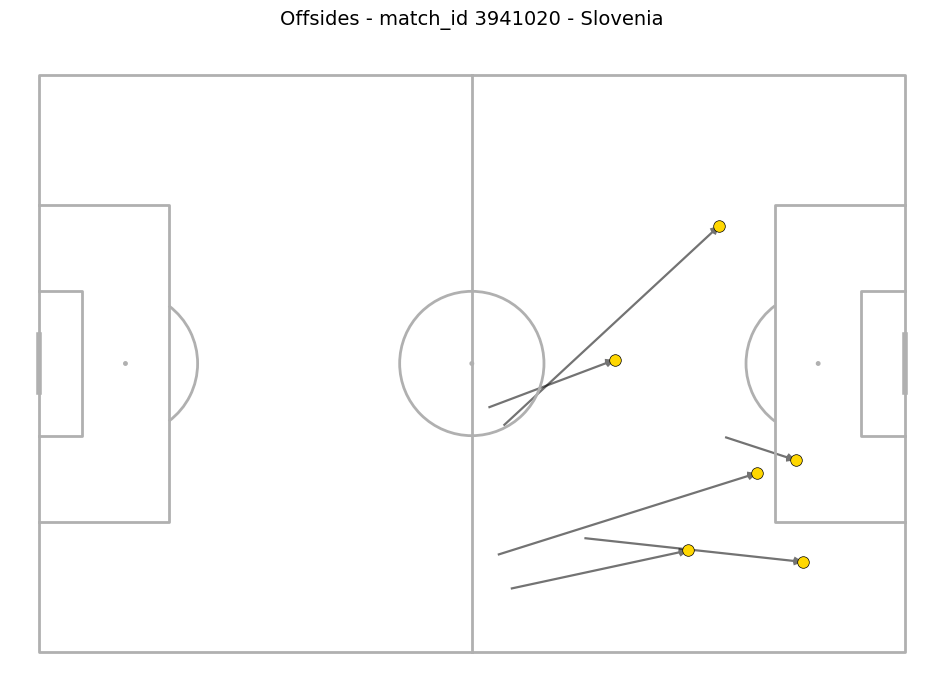

In [64]:
MATCH_ID = int(match_team_counts.iloc[0]["match_id"])
TEAM_MATCH = match_team_counts.iloc[0]["team"]
match_df = offside_targets[(offside_targets["match_id"].eq(MATCH_ID)) & (offside_targets["team"].eq(TEAM_MATCH))].copy()

fig, ax = plot_offside_passes(match_df, title=f"Offsides - match_id {MATCH_ID} - {TEAM_MATCH}", point_color="gold")
plt.show()


15) Capa extra: eventos Offside (type == Offside)

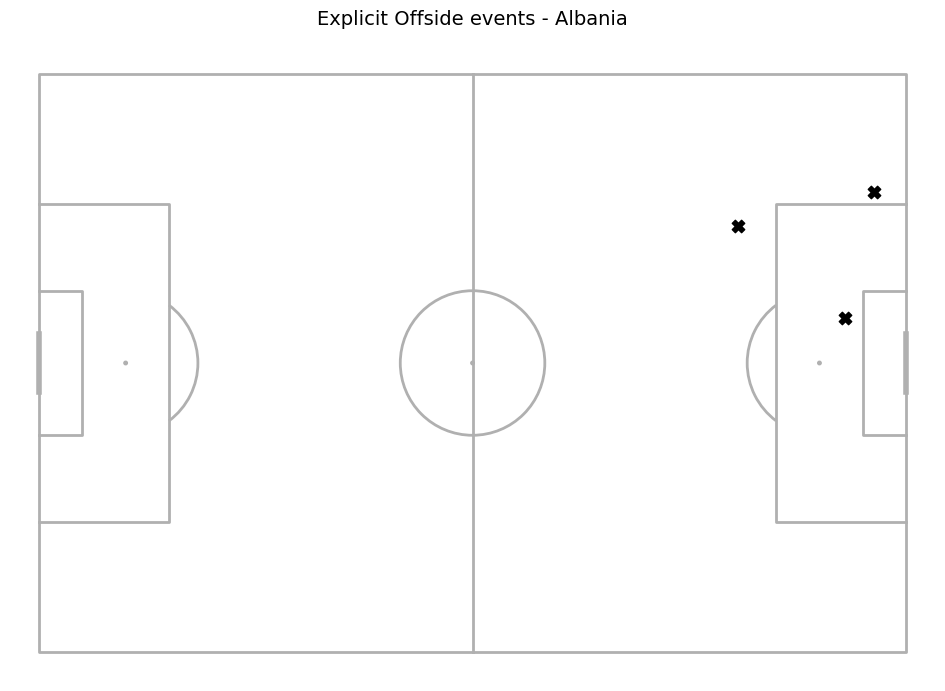

In [65]:
if offside_events.empty:
    print("No hay eventos type == 'Offside' en este dataset.")
else:
    TEAM_EVT = offside_events["team"].dropna().value_counts().index[0]
    evt_df = offside_events[offside_events["team"].eq(TEAM_EVT)].copy()

    pitch, fig, ax = draw_pitch(title=f"Explicit Offside events - {TEAM_EVT}")
    pitch.scatter(evt_df["x"], evt_df["y"], ax=ax, s=80, marker="X", color="black")
    plt.show()

    evt_df[["match_id", "team", "player", "x", "y", "minute", "second"]].head(15)
